#Домашнее задание 1. Реализация модели latent diffusion

##Интро
На семинарах мы познакомились с тем, как обучать диффузионную модель. Эти модели были реализованы через пиксельную диффузию, которую на практике уже никто не использует, потому что это вычислительно сложно обучить. На семинарах было разобрано обучение диффузионной модели. Для обучения вам предлагается обучение модели на датасете `nelorth/oxford-flowers` (https://huggingface.co/datasets/nelorth/oxford-flowers)  

##Цель домашнего задания
Научиться реализовать модель диффузии, модель скрытой диффузии и вносить в нее модификации.

### [5 баллов] Реализация обучения диффузионной модели на новом датасете

В этой части задания вам рекомендуется взять код с семинара и адаптировать его под обучение на новом датасете.

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели и код обучения модели.

#### Imports

In [2]:
import os
import math
import random
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange
import numpy as np
import torch
from torch import nn, einsum
import torch.nn.functional as F

import torch
from torch.utils.data import Dataset

# позволяет PyTorch более эффективно использовать зарезервированную память
# предотвращения "reserved but unallocated"
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print("PYTORCH_CUDA_ALLOC_CONF настроен: expandable_segments=True")

PYTORCH_CUDA_ALLOC_CONF настроен: expandable_segments=True


#### Вспомогательные функции

In [3]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, 4, 2, 1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)



#### Позиционные эмбеддинги

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time) -> torch.Tensor:
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings    

#### Блок ResNet/ConvNeXT

In [5]:
class Block(nn.Module):
    def __init__(self, dim, dim_out, groups = 8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding = 1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift = None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    """https://arxiv.org/abs/1512.03385"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.block1(x)

        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            h = rearrange(time_emb, "b c -> b c 1 1") + h

        h = self.block2(h)
        return h + self.res_conv(x)

class ConvNextBlock(nn.Module):
    """https://arxiv.org/abs/2201.03545"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, mult=2, norm=True):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.GELU(), nn.Linear(time_emb_dim, dim))
            if exists(time_emb_dim)
            else None
        )

        self.ds_conv = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)

        self.net = nn.Sequential(
            nn.GroupNorm(1, dim) if norm else nn.Identity(),
            nn.Conv2d(dim, dim_out * mult, 3, padding=1),
            nn.GELU(),
            nn.GroupNorm(1, dim_out * mult),
            nn.Conv2d(dim_out * mult, dim_out, 3, padding=1),
        )

        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.ds_conv(x)

        if exists(self.mlp) and exists(time_emb):
            assert exists(time_emb), "time embedding must be passed in"
            condition = self.mlp(time_emb)
            h = h + rearrange(condition, "b c -> b c 1 1")

        h = self.net(h)
        return h + self.res_conv(x)

#### Attention

Все равно не могу запустить обучение на RTX 3080 10GB. Не хватает памяти.

Будем пробовать scaled_dot_product_attention

In [6]:
HEADS = 4

# Использует F.scaled_dot_product_attention
class Attention(nn.Module):
    def __init__(self, dim, heads=HEADS, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        print(f"Attention heads: {self.heads} (using memory-efficient scaled_dot_product_attention)")
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        
        # Преобразуем в формат [batch, heads, seq_len, dim_head]
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h (x y) c", h=self.heads), qkv
        )

        # Экономит память на attention matrices
        out = F.scaled_dot_product_attention(q, k, v, scale=self.scale)

        # Преобразуем обратно в пространственный формат
        out = rearrange(out, "b h (x y) c -> b (h c) x y", x=h, y=w)
        return self.to_out(out)


# LinearAttention без изменений
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)

#### Групповая нормализация

In [7]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

#### Условная U-Net

- сеть принимает на вход: 
    - батч зашумленных изображений формы `(batch_size, num_channels, height, width)` 
    - и батч уровней шума формы `(batch_size, 1)` 
- и возвращает тензор формы `(batch_size, num_channels, height, width)`


In [8]:
from torch.utils.checkpoint import checkpoint as gradient_checkpoint

class Unet(nn.Module):
    def __init__(
        self,
        dim,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4, 8),
        channels=3,
        with_time_emb=True,
        resnet_block_groups=8,
        use_convnext=True,
        convnext_mult=2,
        use_gradient_checkpointing=False,  
    ):
        super().__init__()

        # определяем размерности
        self.channels = channels
        self.use_gradient_checkpointing = use_gradient_checkpointing

        init_dim = default(init_dim, dim // 3 * 2)
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        if use_convnext:
            block_klass = partial(ConvNextBlock, mult=convnext_mult)
        else:
            block_klass = partial(ResnetBlock, groups=resnet_block_groups)

        # time embeddings
        if with_time_emb:
            time_dim = dim * 4
            self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(dim),
                nn.Linear(dim, time_dim),
                nn.GELU(),
                nn.Linear(time_dim, time_dim),
            )
        else:
            time_dim = None
            self.time_mlp = None

        # уровни
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(
                nn.ModuleList(
                    [
                        block_klass(dim_in, dim_out, time_emb_dim=time_dim),
                        block_klass(dim_out, dim_out, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)

            self.ups.append(
                nn.ModuleList(
                    [
                        block_klass(dim_out * 2, dim_in, time_emb_dim=time_dim),
                        block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )

        out_dim = default(out_dim, channels)
        self.final_conv = nn.Sequential(
            block_klass(dim, dim), nn.Conv2d(dim, out_dim, 1)
        )

    def forward(self, x, time):
        x = self.init_conv(x)

        t = self.time_mlp(time) if exists(self.time_mlp) else None

        h = []

        # понижение дискретизации (с gradient checkpointing)
        for block1, block2, attn, downsample in self.downs:
            if self.use_gradient_checkpointing and self.training:
                # Используем gradient checkpointing для экономии памяти
                x = gradient_checkpoint(block1, x, t, use_reentrant=False)
                x = gradient_checkpoint(block2, x, t, use_reentrant=False)
                x = gradient_checkpoint(attn, x, use_reentrant=False)
            else:
                x = block1(x, t)
                x = block2(x, t)
                x = attn(x)
            h.append(x)
            x = downsample(x)

        # узкое место (с gradient checkpointing)
        if self.use_gradient_checkpointing and self.training:
            x = gradient_checkpoint(self.mid_block1, x, t, use_reentrant=False)
            x = gradient_checkpoint(self.mid_attn, x, use_reentrant=False)
            x = gradient_checkpoint(self.mid_block2, x, t, use_reentrant=False)
        else:
            x = self.mid_block1(x, t)
            x = self.mid_attn(x)
            x = self.mid_block2(x, t)

        # повышение дискретизации (с gradient checkpointing)
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            if self.use_gradient_checkpointing and self.training:
                x = gradient_checkpoint(block1, x, t, use_reentrant=False)
                x = gradient_checkpoint(block2, x, t, use_reentrant=False)
                x = gradient_checkpoint(attn, x, use_reentrant=False)
            else:
                x = block1(x, t)
                x = block2(x, t)
                x = attn(x)
            x = upsample(x)

        return self.final_conv(x)

#### Определение процесса прямой диффузии

- косинусный график отклонений

In [9]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    косинусный график как в https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start

##### Прямая диффузия q_sample

In [10]:
# прямая диффузия
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

#### Dataset nelorth/oxford-flowers

```shell
# Download dataset using CLI
$ huggingface-cli download nelorth/oxford-flowers --repo-type dataset
$ hf download nelorth/oxford-flowers --repo-type dataset


In [11]:
from datasets import load_dataset

dataset = load_dataset(
    "nelorth/oxford-flowers",
)


In [12]:
# Show dataset information: size, splits, features, etc.
print("Dataset splits:", dataset.keys())
for split in dataset.keys():
    print(f"Split '{split}':")
    print(f"  Number of samples: {len(dataset[split])}")
    print(f"  Number of class labels: {len(dataset[split].features['label'].names)}")
    print(f"  Features: {dataset[split].features}")

# Print the size of the first image in the train split
for i in range(10):
    image = dataset["train"][i]["image"]
    print(f"Image size {i}:", image.size)




Dataset splits: dict_keys(['train', 'test'])
Split 'train':
  Number of samples: 7169
  Number of class labels: 102
  Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['1', '10', '100', '101', '102', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'])}
Split 'test':
  Number of samples: 1020
  Number of class labels: 102
  Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['1', '10', '100', '101', '102', '11', '12', '1

Вывод: 
- Нам нужно ресайзить изображения до одного размера.
- Возьмем пока меньший размер 256x256.

#### Vars

In [13]:
image_size = 256
channels = 3  # RGB цветные изображения (было 1 для grayscale)
batch_size = 40  # H100 Configuration A: 2x increase для использования 80GB памяти (было 64)

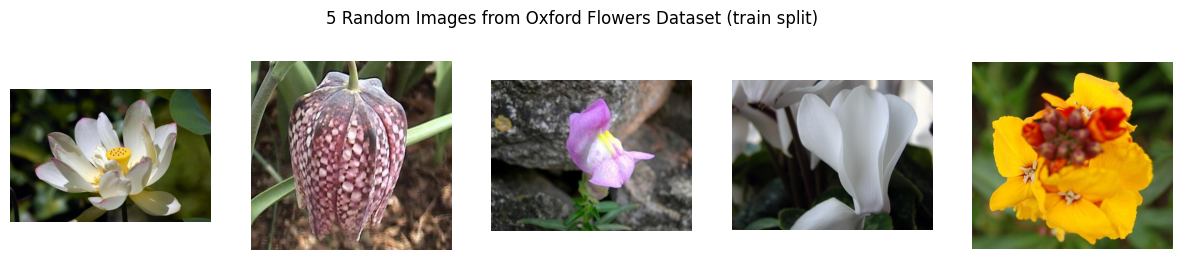

In [14]:
# import matplotlib.pyplot as plt
# import random

random.seed(42)

# Choose 5 random indices from the training split
random_indices = random.sample(range(len(dataset["train"])), 5)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(random_indices):
    image = dataset["train"][idx]["image"]
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
plt.suptitle("5 Random Images from Oxford Flowers Dataset (train split)")
plt.show()


In [15]:
from torchvision import transforms
from torch.utils.data import DataLoader

# определяем трансформации изображения (например, используя torchvision)
transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(),
    # transforms.ToTensor(),
    # transforms.Lambda(lambda t: (t * 2) - 1)
    transforms.Resize(256),                    # Изменяем размер (короткая сторона = 256)
    transforms.CenterCrop(256),                # Обрезаем до квадрата 256x256
    transforms.ToTensor(),                     # Конвертируем в тензор [0, 1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Нормализуем в [-1, 1] для RGB
])

# определяем функцию
def transforms(examples):
    examples["pixel_values"] = [
        # transform(image.convert("L")) for image in examples["image"]
        transform(image.convert("RGB")) for image in examples["image"]
    ]
    del examples["image"]

    return examples

transformed_dataset = dataset.with_transform(transforms).remove_columns("label")

# создаем dataloader
dataloader = DataLoader(
    transformed_dataset["train"], batch_size=batch_size, shuffle=True
)

In [16]:
batch = next(iter(dataloader))
print(batch.keys())

dict_keys(['pixel_values'])


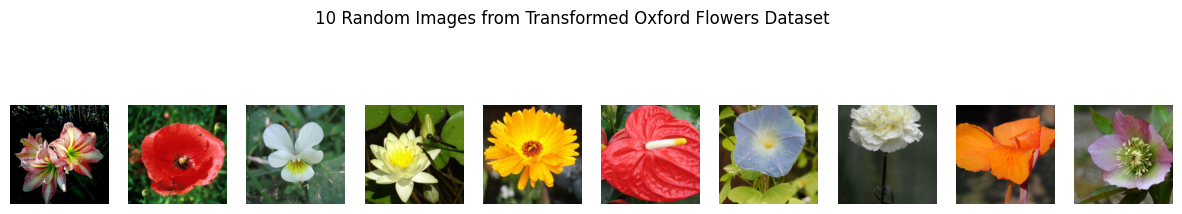

In [17]:
# Get a random batch of 10 images from the dataloader
images = []
count = 0
for batch in dataloader:
    for img in batch["pixel_values"]:
        images.append(img)
        count += 1
        if count == 10:
            break
    if count == 10:
        break

# Convert tensors to numpy and move channels to last dimension
images_np = [img.permute(1, 2, 0).cpu().numpy() for img in images]

# Undo normalization to [0,1] for visualization
images_np = [((img * 0.5) + 0.5).clip(0, 1) for img in images_np]

plt.figure(figsize=(15, 3))
for i, img in enumerate(images_np):
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("10 Random Images from Transformed Oxford Flowers Dataset")
plt.show()


#### Функция потерь p_losses

In [18]:
def p_losses(denoise_model, x_start, t, noise=None, loss_type="l1"):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss

##### alphas, betas, extract, timesteps

In [19]:
timesteps = 200

# определяем beta schedule
betas = cosine_beta_schedule(timesteps=timesteps)
#betas = linear_beta_schedule(timesteps=timesteps)
#betas = quadratic_beta_schedule(timesteps=timesteps)
#betas = sigmoid_beta_schedule(timesteps=timesteps)
# определяем альфа
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# вычисления для диффузии q(x_t | x_{t-1}) и других
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# вычисления для постериорного q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

#### Сэмплирование

In [20]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # В статье "Equation 11"
    # Используем нашу модель (предиктор шума) чтобы предсказать среднее
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Алгоритм 2 - 4-ая строка:
        return model_mean + torch.sqrt(posterior_variance_t) * noise

# Алгоритм 2, но сохраняем изображения:
@torch.no_grad()
def p_sample_loop(model, shape):
    device = next(model.parameters()).device

    b = shape[0]
    # начинаем с чистого шума (для каждого примера в батче)
    img = torch.randn(shape, device=device)
    imgs = []

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        imgs.append(img.cpu().numpy())
    return imgs

@torch.no_grad()
def sample(model, image_size, batch_size=16, channels=3):
    return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))

In [21]:
@torch.no_grad()
def p_sample_loop_skip_intermediate(
    model, shape, save_intermediate=False, clear_cache_every=50
):
    """
    Memory-efficient версия p_sample_loop
    
    Args:
        model: модель диффузии
        shape: форма выходных изображений (batch, channels, height, width)
        save_intermediate: если True, сохраняет все промежуточные шаги (как в оригинале)
        clear_cache_every: очищать CUDA кэш каждые N шагов
    
    Returns:
        если save_intermediate=True: список всех промежуточных изображений
        если save_intermediate=False: только финальное изображение [final_img]
    """
    device = next(model.parameters()).device

    b = shape[0]
    # начинаем с чистого шума (для каждого примера в батче)
    img = torch.randn(shape, device=device)
    imgs = [] if save_intermediate else None

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        
        # сохраняем только если требуется
        if save_intermediate:
            imgs.append(img.cpu().numpy())
        
        # периодическая очистка кэша для предотвращения фрагментации
        if i % clear_cache_every == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # возвращаем либо все шаги, либо только финальный результат
    if save_intermediate:
        return imgs
    else:
        return [img.cpu().numpy()]

@torch.no_grad()
def sample_skip_intermediate(
    model, image_size, batch_size=1, channels=3, save_intermediate=False
):
    return p_sample_loop_skip_intermediate(
        model, 
        shape=(batch_size, channels, image_size, image_size),
        save_intermediate=save_intermediate
    )

#### Обучение

##### Периодические сохранения и сэмплирование

In [22]:
from pathlib import Path

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

results_folder = Path("./results")
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 1000

In [23]:
import gc

# Удаляем старые объекты из памяти
objects_to_delete = ['model', 'optimizer', 'vae', 'scaler']
for obj_name in objects_to_delete:
    if obj_name in globals():
        del globals()[obj_name]
        print(f"{obj_name} удален из памяти")

# Сборка мусора Python
gc.collect()
print("garbage collection выполнен")

# Очищаем кэш CUDA
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache очищен")
    
    torch.cuda.reset_peak_memory_stats()
    print("CUDA peak memory stats сброшены")
    
    # НОВОЕ: Очистка cuFFT plan cache (рекомендация PyTorch)
    # Это освобождает дополнительную память, используемую FFT операциями
    torch.backends.cuda.cufft_plan_cache.clear()
    print("cuFFT plan cache очищен")

# Проверяем использование памяти
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    
    print(f"\n=== Состояние GPU памяти ===")
    print(f"Всего: {total:.2f} GB")
    print(f"Занято: {allocated:.2f} GB")
    print(f"Зарезервировано: {reserved:.2f} GB")
    print(f"Свободно: {total - allocated:.2f} GB")
    print("=" * 30)
    
    # Предупреждение, если память не освобождена
    if allocated > 1.0:
        print(f"\n{allocated:.2f} GB все еще занято!")
    elif reserved > 1.0:
        print(f"\n{reserved:.2f} GB зарезервировано но не используется")
        print("PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True должен помочь.")
    else:
        print("\nПамять освобождена")

garbage collection выполнен
CUDA cache очищен
CUDA peak memory stats сброшены
cuFFT plan cache очищен

=== Состояние GPU памяти ===
Всего: 79.18 GB
Занято: 0.00 GB
Зарезервировано: 0.00 GB
Свободно: 79.18 GB

Память освобождена


##### Создаем модель и оптимизатор

In [24]:
from torch.optim import Adam
from diffusers.optimization import get_cosine_schedule_with_warmup

device = "cuda" if torch.cuda.is_available() else "cpu"

epochs = 100


# H100 Configuration A: Optimal settings for 80GB VRAM
model = Unet(
    # dim - это базовое число каналов в UNet, НЕ размер изображения!
    dim=96,  # H100: увеличено с 48 (2x) для лучшей модели
    channels=channels,
    dim_mults=(1, 2, 4, 8),  # H100: добавлен 4-й уровень, каналы: [96, 192, 384, 768]
    use_gradient_checkpointing=False  # H100: выключено - достаточно памяти, +20% скорости
)
model.to(device)

# ИСПРАВЛЕНИЕ 1: Уменьшен learning rate с 1e-3 до 1e-4 (10x reduction)
# Это предотвращает gradient explosion и улучшает стабильность обучения
optimizer = Adam(model.parameters(), lr=1e-4)

# ИСПРАВЛЕНИЕ 2: Добавлен LR scheduler с warmup
# Cosine scheduler с warmup предотвращает ранние проблемы со стабильностью
num_training_steps = len(dataloader) * epochs
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,  # Standard warmup: 500 steps (из HuggingFace Diffusers best practices)
    num_training_steps=num_training_steps
)

# Вывод информации о модели и обучении
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / 1024**2

print(f"Всего параметров: {total_params:,}")
print(f"Размер модели: ~{model_size_mb:.1f} МБ (float32)")
print(f"Каналы: {[96, 192, 384, 768]}")
print(f"  - Модель: ~{model_size_mb:.1f} МБ")
print(f"  - Batch данные: ~{batch_size * 3 * 256 * 256 * 4 / 1024**2:.0f} МБ")
print(f"\n=== Конфигурация обучения ===")
print(f"Learning rate: 1e-4 (было 1e-3)")
print(f"LR scheduler: Cosine с warmup")
print(f"Warmup steps: 500")
print(f"Total training steps: {num_training_steps}")
print(f"Gradient clipping: max_norm=1.0 (будет применен в цикле обучения)")
print("=" * 30)

Attention heads: 4 (using memory-efficient scaled_dot_product_attention)
Всего параметров: 128,746,659
Размер модели: ~491.1 МБ (float32)
Каналы: [96, 192, 384, 768]
  - Модель: ~491.1 МБ
  - Batch данные: ~30 МБ

=== Конфигурация обучения ===
Learning rate: 1e-4 (было 1e-3)
LR scheduler: Cosine с warmup
Warmup steps: 500
Total training steps: 18000
Gradient clipping: max_norm=1.0 (будет применен в цикле обучения)


##### Цикл обучения

In [ ]:
# raise AssertionError("Don't run training cell")  # TODO: Temporary break to skip training

from torchvision.utils import save_image
import time

# Включаем режим обучения
model.train()

# Инициализация переменных для отслеживания
# best_loss = float('inf')
# best_model_path = results_folder / "best_model.pt"
total_steps = 0
start_time_total = time.time()

# Сбрасываем статистику памяти перед обучением
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    initial_mem = torch.cuda.memory_allocated(0) / 1024**3
    print(f"начальная память gpu: {initial_mem:.2f} gb\n")

for epoch in range(epochs):  
    epoch_start_time = time.time()
    epoch_loss_sum = 0.0
    epoch_steps = 0
    
    print(f"\nepoch {epoch+1}/{epochs} " + "-" * 50)
    for step, batch in enumerate(dataloader):
        step_start_time = time.time()
        optimizer.zero_grad()

        batch_size = batch["pixel_values"].shape[0]
        batch = batch["pixel_values"].to(device)

        # Algorithm 1 line 3: sample t uniformally for every example in the batch
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        loss = p_losses(model, batch, t, loss_type="huber")
        
        # Safety check: проверка на NaN/Inf
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n[warning] критическая ошибка: loss = {loss.item()} на шаге {step}")
            print("обучение остановлено!")
            break
        
        epoch_loss_sum += loss.item()
        epoch_steps += 1

        # Мониторинг памяти и вывод каждые 100 шагов
        if step % 100 == 0:
            step_time = time.time() - step_start_time
            avg_loss = epoch_loss_sum / epoch_steps
            
            # Вычисление ETA
            elapsed_total = time.time() - start_time_total
            steps_done = total_steps + step
            steps_remaining = (epochs * len(dataloader)) - steps_done
            eta_seconds = (elapsed_total / max(steps_done, 1)) * steps_remaining
            eta_str = time.strftime("%H:%M:%S", time.gmtime(eta_seconds))
            
            # ИСПРАВЛЕНИЕ 4: Добавлен вывод learning rate
            current_lr = lr_scheduler.get_last_lr()[0]
            
            if torch.cuda.is_available():
                current_mem = torch.cuda.memory_allocated(0) / 1024**3
                peak_mem = torch.cuda.max_memory_allocated(0) / 1024**3
                print(f"step {step:4d} | loss: {loss.item():.4f} (avg: {avg_loss:.4f}) | "
                      f"lr: {current_lr:.2e} | "
                      f"gpu: {current_mem:.2f} gb | peak: {peak_mem:.2f} gb | "
                      f"time: {step_time:.2f}s | eta: {eta_str}")
            else:
                print(f"step {step:4d} | loss: {loss.item():.4f} (avg: {avg_loss:.4f}) | "
                      f"lr: {current_lr:.2e} | "
                      f"time: {step_time:.2f}s | eta: {eta_str}")
           
        loss.backward()
        
        # ИСПРАВЛЕНИЕ 3: Добавлен gradient clipping (max_norm=1.0 - стандарт для diffusion моделей)
        # Это предотвращает gradient explosion, который вызывал черные изображения на epoch 22
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # ИСПРАВЛЕНИЕ 3: Добавлен lr_scheduler.step() после каждого шага оптимизатора
        # Scheduler обновляет learning rate согласно cosine schedule с warmup
        lr_scheduler.step()
    
    # Статистика по эпохе
    epoch_time = time.time() - epoch_start_time
    epoch_avg_loss = epoch_loss_sum / epoch_steps
    current_lr = lr_scheduler.get_last_lr()[0]
    print(f"epoch {epoch+1} завершена за {epoch_time/60:.2f} мин | avg loss: {epoch_avg_loss:.4f} | lr: {current_lr:.2e}")
    
    # Save samples and model every 4 epochs
    if (epoch + 1) % 2 == 0:
        print(f"  [saving] генерация сэмплов и сохранение модели...")
        
        # Generate samples using memory-efficient function
        all_images_list = []
        batches = num_to_groups(4, batch_size)
        for n in batches:
            samples = sample_skip_intermediate(
                model, 
                image_size=image_size, 
                batch_size=n, 
                channels=channels, 
                save_intermediate=False
            )
            # samples[0] is numpy array of shape (n, channels, height, width)
            # Convert to torch tensor
            all_images_list.append(torch.from_numpy(samples[0]))
        
        all_images = torch.cat(all_images_list, dim=0)
        all_images = (all_images + 1) * 0.5
        save_image(all_images, str(results_folder / f'sample-epoch{epoch+1}.png'), nrow=6)
        model_filename = str(results_folder / f'model-epoch{epoch+1}.pt')
        torch.save({
            'epoch': epoch,
            'step': 0,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_avg_loss,
        }, model_filename)
        print(f"  [saved] модель и сэмплы сохранены для эпохи {epoch+1}, loss: {epoch_avg_loss:.4f}")
        
        # Очищаем кэш после сэмплирования
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print(f"  saved sample-epoch{epoch+1}.png | gpu cache cleared")
    
    total_steps += len(dataloader)

# Финальная статистика
total_time = time.time() - start_time_total
print(f"\n{'='*50}")
print("обучение завершено!")
print(f"общее время: {total_time/3600:.2f} часов ({total_time/60:.2f} минут)")
print(f"{'='*50}")

начальная память gpu: 0.48 gb


epoch 1/100 --------------------------------------------------
step    0 | loss: 0.5001 (avg: 0.5001) | lr: 0.00e+00 | gpu: 72.54 gb | peak: 75.29 gb | time: 0.66s | eta: 04:10:54


##### Результаты других запусков обучения

---

1. Первый успешный запуск. Запускается обучение на RTX 3080 10GB

```text
Начальная память GPU: 0.02 GB


==================================================
Epoch 1/5
==================================================

Step    0 | Loss: 0.5007 | GPU: 1.84 GB | Peak: 5.22 GB
Step  100 | Loss: 0.4070 | GPU: 1.89 GB | Peak: 8.91 GB
Step  200 | Loss: 0.0357 | GPU: 1.89 GB | Peak: 8.91 GB
Step  300 | Loss: 0.0234 | GPU: 1.89 GB | Peak: 8.91 GB
Step  400 | Loss: 0.0447 | GPU: 1.89 GB | Peak: 8.91 GB
...
```

---

2. Удалось запустить 5 эпох на RTX 3080 10GB

```text
начальная память gpu: 0.02 gb


==================================================
epoch 1/5
==================================================

step    0 | loss: 0.4865 (avg: 0.4865) | gpu: 1.84 gb | peak: 5.22 gb | time: 0.35s | eta: 00:27:55
  [saved] лучшая модель сохранена! loss: 0.4865
step  100 | loss: 0.4065 (avg: 0.4571) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:47:28
  [saved] лучшая модель сохранена! loss: 0.4571
step  200 | loss: 0.0666 (avg: 0.3330) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:46:34
  [saved] лучшая модель сохранена! loss: 0.3330
step  300 | loss: 0.0189 (avg: 0.2367) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:45:32
  [saved] лучшая модель сохранена! loss: 0.2367
step  400 | loss: 0.0144 (avg: 0.1863) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:44:30
  [saved] лучшая модель сохранена! loss: 0.1863
step  500 | loss: 0.0228 (avg: 0.1555) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:43:26
  [saved] лучшая модель сохранена! loss: 0.1555
step  600 | loss: 0.0505 (avg: 0.1347) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:42:23
  [saved] лучшая модель сохранена! loss: 0.1347
step  700 | loss: 0.0421 (avg: 0.1194) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:41:18
  [saved] лучшая модель сохранена! loss: 0.1194
step  800 | loss: 0.0482 (avg: 0.1079) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:40:13
  [saved] лучшая модель сохранена! loss: 0.1079

epoch 1 завершена за 9.78 мин | avg loss: 0.0991

...
...
...

epoch 4 завершена за 9.79 мин | avg loss: 0.0151

==================================================
epoch 5/5
==================================================

step    0 | loss: 0.0140 (avg: 0.0140) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.25s | eta: 00:09:47
step  100 | loss: 0.0164 (avg: 0.0158) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:08:42
step  200 | loss: 0.0096 (avg: 0.0157) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:07:36
step  300 | loss: 0.0178 (avg: 0.0149) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:06:31
step  400 | loss: 0.0537 (avg: 0.0148) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:05:25
step  500 | loss: 0.0108 (avg: 0.0145) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:04:20
step  600 | loss: 0.0226 (avg: 0.0144) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.41s | eta: 00:03:14
step  700 | loss: 0.0206 (avg: 0.0147) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:02:09
step  800 | loss: 0.0153 (avg: 0.0147) | gpu: 1.89 gb | peak: 8.91 gb | time: 0.42s | eta: 00:01:03

epoch 5 завершена за 9.80 мин | avg loss: 0.0146

==================================================
обучение завершено!
общее время: 0.82 часов (48.98 минут)
лучший loss: 0.0066
лучшая модель сохранена в: results/best_model.pt
==================================================
```

---

3. Переехал на ВМ с NVIDIA H100 80GB HBM3. 

- Запустил 5 эпох.
- Обучение 10 мин.

```text
...
epoch 5/5
==================================================

step    0 | loss: 0.0256 (avg: 0.0256) | gpu: 14.60 gb | peak: 70.69 gb | time: 0.30s | eta: 00:01:51
  [saved] лучшая модель сохранена! loss: 0.0256
step  100 | loss: 0.0231 (avg: 0.0261) | gpu: 14.60 gb | peak: 70.69 gb | time: 0.55s | eta: 00:00:12

epoch 5 завершена за 1.85 мин | avg loss: 0.0260

==================================================
обучение завершено!
общее время: 0.15 часов (9.27 минут)
лучший loss: 0.0256
лучшая модель сохранена в: results/best_model.pt
==================================================
```

4. Запуск на H100 на 50 эпох.

```text
...

==================================================
epoch 50/50
==================================================

step    0 | loss: 0.2817 (avg: 0.2817) | gpu: 14.60 gb | peak: 70.69 gb | time: 0.30s | eta: 00:01:50
step  100 | loss: 0.2667 (avg: 0.2706) | gpu: 14.60 gb | peak: 70.69 gb | time: 0.55s | eta: 00:00:12

epoch 50 завершена за 1.85 мин | avg loss: 0.2688

==================================================
обучение завершено!
общее время: 1.54 часов (92.48 минут)
лучший loss: 0.0122
лучшая модель сохранена в: results/best_model.pt
==================================================

5. Здесь у меня было еще 2 версии этого ноутбука они оба зашли в тупик.
Вернулся к этой версии.

Понял, что save best model по loss это неправильно для диффузионных моделей.
Запущу на 100 эпох и буду смотреть сэмплы эпох.

```

#### Визуализация генераций

In [ ]:
# Очищаем CUDA кэш перед сэмплированием
import gc
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    mem_before = torch.cuda.memory_allocated(0) / 1024**3
    print(f"gpu память перед сэмплированием: {mem_before:.2f} gb")


In [ ]:
# Загрузка лучшей модели
def load_best_model(model, optimizer, checkpoint_path):
    """
    Загружает лучшую модель из чекпоинта
    
    Args:
        model: модель для загрузки весов
        optimizer: оптимизатор для загрузки состояния (опционально)
        checkpoint_path: путь к файлу чекпоинта
    
    Returns:
        dict: информация о загруженной модели
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    info = {
        'epoch': checkpoint['epoch'],
        'step': checkpoint['step'],
        'loss': checkpoint['loss']
    }
    
    print(f"модель загружена из эпохи {info['epoch']}, шага {info['step']}")
    print(f"loss: {info['loss']:.4f}")
    
    return info

info = load_best_model(model, optimizer, results_folder / "best_model.pt")
model.eval()  # Переключаем в режим inference
# можно генерировать изображения с помощью sample()

модель загружена из эпохи 14, шага 0
loss: 0.0122


Unet(
  (init_conv): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=48, out_features=192, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=192, out_features=192, bias=True)
  )
  (downs): ModuleList(
    (0): ModuleList(
      (0): ConvNextBlock(
        (mlp): Sequential(
          (0): GELU(approximate='none')
          (1): Linear(in_features=192, out_features=32, bias=True)
        )
        (ds_conv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=32)
        (net): Sequential(
          (0): GroupNorm(1, 32, eps=1e-05, affine=True)
          (1): Conv2d(32, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): GELU(approximate='none')
          (3): GroupNorm(1, 96, eps=1e-05, affine=True)
          (4): Conv2d(96, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (res_conv): Conv2d

генерация 8 изображений...
изображения 1-8/8


sampling loop time step:   0%|          | 0/200 [00:00<?, ?it/s]

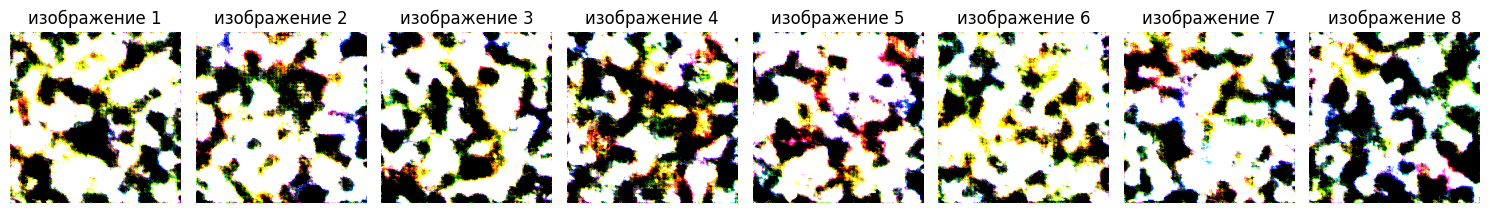

In [ ]:
num_samples = 8  # количество изображений для генерации
gen_batch_size = 8
generated_images = []

print(f"генерация {num_samples} изображений...")
for i in range(0, num_samples, gen_batch_size):
    current_batch_size = min(gen_batch_size, num_samples - i)
    print(f"изображения {i+1}-{i+current_batch_size}/{num_samples}")
    
    # очищаем кэш перед каждым сэмплированием
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # генерируем батч изображений
    samples = sample_skip_intermediate(
        model, image_size=image_size, batch_size=current_batch_size, channels=channels, save_intermediate=False
    )
    
    # samples[0] - это numpy array формы (batch_size, channels, height, width)
    # добавляем все изображения из батча
    for j in range(current_batch_size):
        generated_images.append(samples[0][j])

# Debug: проверяем диапазон значений ПЕРЕД денормализации
# for i, img in enumerate(generated_images[:2]):  # проверяем первые 2 изображения
#     print(f"изображение {i+1}: min={img.min():.2f}, max={img.max():.2f}")

# визуализация всех сгенерированных изображений
plt.figure(figsize=(15, 4))
for i, img in enumerate(generated_images):
    plt.subplot(1, num_samples, i + 1)
    img_denorm = (img.transpose(1, 2, 0) * 0.5 + 0.5).clip(0, 1)
    plt.imshow(img_denorm)
    plt.axis("off")
    plt.title(f"изображение {i+1}")
plt.tight_layout()
plt.show()

#### Результаты 1-ой генерации

- Цветы на картинках не очень видны, точнее модель бесполезна.
- Буду пробовать запускать на ВМ с большими GPU ресурсами, например H100.
    - увеличить кол-во эпох 50-100
    - уменьшить learning rate lr=1e-4
    - добавить EMA
    - попробовать dim=64 вместо 48
    - попробовать dim_mults=(1, 2, 4)

---

Ошибки при генерации:
```text
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1813.2427..1513.0697].

```
- Значения пикселей в диапазоне отличном от [0, 1] - модель не научилась правильному масштабированию

Скриншот результатов генерации:
- [01-visual-01-image01.png](homework/hw01/doc/01-visual-01-image01.png)

---

Пофиксены ошибки денормализации.
- [01-visual-02-image.png](homework/hw01/doc/01-visual-02-image.png)
- [nvtop](homework/hw01/doc/01-visual-02-nvtop.png)

---

### [3 балла] Реализация обучения модели latent diffusion

Напоминание про реализацию модели: [Latent Diffusion](https://nn.labml.ai/diffusion/stable_diffusion/latent_diffusion.html)

Для того чтобы из кода обучения Diffusion получить обучение Latent Diffusion, вам нужно добавить VQ-VAE и обрабатывать изображения с помощью `vae.encode`. Далее полученные latent, подаются в стандартный пайплайн обучения. Учтите, что latent имеет меньшую размерность и вам может понадобиться уменьшить число слоев в архитектуре UNet.

В качестве модели VQ-VAE вы можете воспользоваться предобученным VQ-VAE от Stable diffusion.

**Ожидаемый результат.** В качестве результатов модели от вас требуется предоставить визуализации генераций, полученных от вашей модели, и код обучения модели.

In [ ]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


In [ ]:
# your code

### [2 балла] Анализ влияния scheduler на качество генерации

 На качество генерации может влиять используемый scheduler и число шагов, поэтому в этой части домашнего задания, вам предлагается происследовать визуально как scheduler и число шагов влияют на качество генерации. Вам предлагается рассмотреть качество генерации на 10 различных числах шагов,  используя различные scheduler.


 В качестве scheduler предлагается стандартный DDPM, DDIM, DPMSolver (другие scheduler не воспрещаются). Обратите внимание, что DDIM и DPMSolver являются детерминированными scheduler, а значит, результат у них должен получаться одиннаковый.

 **Ожидаемый результат.** В качестве результатов в этом пункте от вас требуется предоставить визуализации картинок в различных вариации числа шагов и scheduler и сделать выводы, какие параметры лучше использовать. Вы можете выполнить эту часть, не используя обученную выше модель, а используя стандартные pipeline StableDiffusion

In [ ]:
# your code + visualizations

### Дополнительное задание [дополнительный 1 балл]. Модификации conditional guidance*
*Дополнительный балл не умножается на коэффициент домашнего задания*

---

Далее вам предлагается реализовать conditional guidance на этом датасете. Как уже упоминалось на лекции механизм conditional guidance позволяет вам генерировать изображения с выбранными вами условиями (картинки определенных цветков, например). На семинаре 2 был показан участок кода, который реализовал условную генерацию, однако для этого вам нужно добавить прокидывание условия в UNet и чуть поменять процесс условной генерации. При реализации вы можете опираться адаптировать следующую [реализацию](https://github.com/TeaPearce/Conditional_Diffusion_MNIST).

**Ожидаемый результат.** В качестве результатов модели, от вас требуется предоставить визуализации генераций, полученных от вашей модели, и код обучения модели.
